In [1]:
import torch
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from dualneuron.twins import registry
from dualneuron.twins.nets import load_model
from dualneuron.dream.axis import population_context, sampled_axis
from dualneuron.synthesis.ascend import fourier_ascending, pixel_ascending
from dualneuron.synthesis.visualize import blend, plot_group
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

[HAMI-core Msg(10373:139716094264384:libvgpu.c:870)]: Initializing.....
[HAMI-core Warn(10373:139716094264384:multiprocess_memory_limit.c:911)]: Kick dead proc 10219 (proc_alive check)
[HAMI-core Msg(10373:139716094264384:libvgpu.c:909)]: Initialized


In [10]:
# ---------------------------------------------------------------------------
AREA, BACKBONE = 'v4', 'dino'   # any (area, backbone) whose full-field screening exists
NEURON         = 6               # must be well-predicted for this twin
SEEDS          = 2               # one LEI + one MEI per seed
AXIS_POOL      = 50              # extreme pool per pole the axis is drawn from
AXIS_SAMPLE    = 5               # images drawn from each pool, per seed
AXIS_DATASET   = 'rendered'      # 'imagenet' or 'rendered': the corpus the poles come from
# ---------------------------------------------------------------------------

In [11]:
spec = registry.resolve(AREA, BACKBONE)

function = load_model(
    architecture=spec.arch,
    ensemble=True,
    centered=True,
    weights_dir=registry.weights_dir(AREA, BACKBONE),
    device=device,
)

# The screening -> z-scored population matrix, loaded once; the axis itself is drawn per seed.
ctx = population_context(AREA, BACKBONE, neurons=[NEURON], dataset=AXIS_DATASET, field='full')
target_norm = registry.resolve_synth_norm(AREA, BACKBONE)

print(f'{AREA}/{BACKBONE}  neuron {NEURON}  method={spec.synth_method}  '
      f'norm={target_norm:.2f}  values_range={spec.synth_values_range}')

v4/dino  neuron 6  method=fourier  norm=88.13  values_range=(-1.905, 2.375)


In [14]:
ascend = {'fourier': fourier_ascending, 'pixel': pixel_ascending}[spec.synth_method]
method_kwargs = {
    'fourier': dict(magnitude_path='natural_rgb.npy', learning_rate=1.0, range_fn='sigmoid'),
    'pixel': dict(channels=spec.channels, learning_rate=0.05, optimizer='adam', init_std=0.01,
                  blur_schedule='cosine', sigma_max=1.0, sigma_min=0.1),
}[spec.synth_method]

results = []

for seed in range(SEEDS):
    torch.manual_seed(seed)
    np.random.seed(seed)

    # A fresh subsample of the neuron's extreme pools per seed, so each seed ascends a slightly
    # different direction and the pair samples the pole's invariances.
    axis = sampled_axis(
        ctx, NEURON,
        pool=AXIS_POOL,
        n_sample=AXIS_SAMPLE,
        rng=np.random.RandomState(seed),
    )

    for pole in [-1, 1]:                      # -1 = LEI, +1 = MEI
        result = ascend(
            objective_function=None,
            population_function=function,
            target_index=NEURON,
            pole=float(pole),
            population_axis=axis,
            population_mean=ctx['mean'],
            population_std=ctx['std'],
            population_support=ctx['support'],
            axis_only=True,
            image_size=spec.input_size,
            init_image=None,
            total_steps=144,
            lr_schedule=True,
            eta_min=0.0,
            noise=0.08,
            values_range=spec.synth_values_range,
            nb_crops=4,
            box_size=(1.0, 0.1),
            target_norm=None,
            tv_weight=0.0,
            jitter_std=0.10,
            oversample=1,
            reflect_pad_frac=0.0,
            device=device,
            verbose=True,
            save_all_steps=False,
            **method_kwargs,
        )
        results.append(result)

with torch.no_grad():
    images = torch.stack([r['image'] for r in results]).to(device)
    responses = function(images)[:, NEURON].cpu().numpy()

natural = np.sort(np.load(registry.screening_path(
    AREA, BACKBONE, AXIS_DATASET, 'responses', field='full'))[f'unit_{NEURON}'])
for seed in range(SEEDS):
    lei, mei = responses[2 * seed], responses[2 * seed + 1]
    print(f'seed {seed}:  LEI {lei:7.3f} (p{(natural < lei).mean() * 100:5.2f})   '
          f'MEI {mei:7.3f} (p{(natural < mei).mean() * 100:6.2f})')
print(f'\nnatural full-field range for neuron {NEURON}: '
      f'[{natural.min():.3f}, {natural.max():.3f}]  n={len(natural)}')

Activation: 0.5781:   1%|          | 1/144 [00:00<00:27,  5.29it/s]

Activation: 1.9976: 100%|██████████| 144/144 [00:26<00:00,  5.54it/s]


seed 0:  LEI   0.273 (p 0.00)   MEI   1.956 (p100.00)
seed 1:  LEI   0.247 (p 0.00)   MEI   1.998 (p100.00)

natural full-field range for neuron 6: [0.266, 1.916]  n=200000


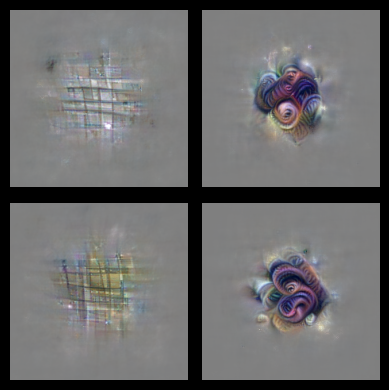

In [15]:
poles = []

for result in results:
    image = result['image']
    alpha = result['alpha']
    pole = blend(image, alpha, alphacut=90.0, boost=2.0, bg_value=0.5)
    poles.append(pole)

plot_group(poles, cols=2)   # rows = seeds, columns = LEI | MEI